In [471]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score



In [472]:
# import pandas as pd
# from scipy.stats import mannwhitneyu

# # Cargar el dataframe
# df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)

# # Filtrar los grupos de relapse y cured
# relapse = df[df['group_name'] == 1]
# cured = df[df['group_name'] == 0]

# # Lista de columnas que representan las características (excluyendo 'group_name' u otras columnas no numéricas)
# feature_columns = [col for col in df.columns if col != 'group_name']  # Asegúrate de excluir la columna 'group_name'

# # Diccionario para almacenar los resultados
# results = {}

# # Aplicar el test de Mann-Whitney U a cada característica
# for feature in feature_columns:
#     stat, p_value = mannwhitneyu(relapse[feature], cured[feature])
#     results[feature] = {'statistic': stat, 'p_value': p_value}

# # Convertir los resultados en un DataFrame para mostrar
# results_df = pd.DataFrame(results).T

# # Mostrar los resultados
# print(results_df)

# # Comprobar cuáles características son estadísticamente significativas
# significant_features = results_df[results_df['p_value'] < 0.05]
# print("\nCaracterísticas estadísticamente significativas (p < 0.05):")
# print(significant_features)




In [473]:
# import pandas as pd
# from pingouin import multivariate_normality
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# import pandas as pd
# from pingouin import multivariate_normality

# # Cargar tu dataset (simulación)
# df = pd.read_csv("csvs/datos_allcases_classweights_lagfeatures_after_reducing_var_corr.csv")

# # 1️⃣ Seleccionar solo las columnas numéricas (sin ID ni fechas)
# df_numeric = df.drop(columns=["m_id", "day_of_study"])  

# # 2️⃣ Imputar NaN con la media (puedes cambiar a mediana si hay outliers)
# imputer = SimpleImputer(strategy="mean")
# df_imputed = imputer.fit_transform(df_numeric)

# # 3️⃣ Escalar con StandardScaler
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df_imputed)
# from sklearn.decomposition import PCA
# pca = PCA(n_components=10)  # Reducir a 10 componentes
# df_pca = pca.fit_transform(df_scaled)

# # 4️⃣ Aplicar test de normalidad multivariante
# test = multivariate_normality(df_pca, alpha=0.05)
# print(test)



In [474]:
from scipy.stats import normaltest

df = pd.read_csv("input/features/radiomics_final_features__new_fixed_final.csv")

for column in df.columns[3:]:  # Saltar columnas como 'group_name', 'm_id', 'day_of_study'
    stat, p = normaltest(df[column])
    print(f'{column}: p = {p:.5f} -> {"Normal" if p > 0.05 else "Not normal"}')


original_shape2D_Elongation: p = 0.00000 -> Not normal
original_shape2D_MajorAxisLength: p = 0.00002 -> Not normal
original_shape2D_MaximumDiameter: p = 0.00015 -> Not normal
original_shape2D_MeshSurface: p = 0.00000 -> Not normal
original_shape2D_MinorAxisLength: p = 0.00000 -> Not normal
original_shape2D_Perimeter: p = 0.00050 -> Not normal
original_shape2D_PerimeterSurfaceRatio: p = 0.00000 -> Not normal
original_shape2D_PixelSurface: p = 0.00000 -> Not normal
original_shape2D_Sphericity: p = 0.00000 -> Not normal
original_firstorder_10Percentile: p = 0.00097 -> Not normal
original_firstorder_90Percentile: p = 0.00000 -> Not normal
original_firstorder_Energy: p = 0.00000 -> Not normal
original_firstorder_Entropy: p = 0.00002 -> Not normal
original_firstorder_InterquartileRange: p = 0.00000 -> Not normal
original_firstorder_Kurtosis: p = 0.00000 -> Not normal
original_firstorder_Maximum: p = 0.01138 -> Not normal
original_firstorder_MeanAbsoluteDeviation: p = 0.00000 -> Not normal
or

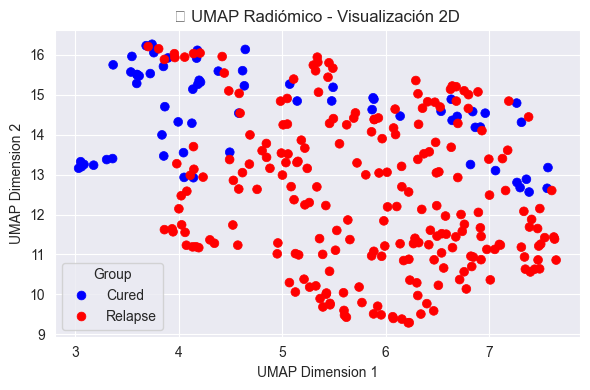

In [475]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import umap.umap_ as umap

# 📌 Cargar datos
X = pd.read_csv("data_to_use.csv")

# 🎯 Extraer etiquetas y eliminar del dataset antes de reducción
y = X['group_name']
X = X.drop(columns=['group_name'])

# 📌 0. Imputar NaN si los hay
X_imputed = SimpleImputer(strategy='mean').fit_transform(X)

# 📌 1. Normalización
X_scaled = StandardScaler().fit_transform(X_imputed)

# 📌 2D UMAP
X_umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
).fit_transform(X_scaled)

# 🎨 Preparar DataFrame para seaborn
df_plot = pd.DataFrame(X_umap_2d, columns=['UMAP Dimension 1', 'UMAP Dimension 2'])
df_plot['Group'] = y.map({0: 'Relapse', 1: 'Cured'})

# 📊 Plot con seaborn
sns.set_style("darkgrid")
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_plot,
    x='UMAP Dimension 1',
    y='UMAP Dimension 2',
    hue='Group',
    palette={'Relapse': 'red', 'Cured': 'blue'},
    edgecolor=None,
    alpha=1,
    s=40
)
plt.title("🌈 UMAP Radiómico - Visualización 2D", fontsize=12)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title='Group')
plt.tight_layout()
plt.show()


In [476]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# import umap.umap_ as umap  # O simplemente: import umap

# # 📌 Cargar datos
# X = pd.read_csv("data_to_use.csv")

# # 🎯 Extraer etiquetas y eliminar del dataset antes de reducción
# y = X['group_name']
# X = X.drop(columns=['group_name'])

# # 📌 0. Imputar NaN si los hay
# imputer = SimpleImputer(strategy='mean')
# X_imputed = imputer.fit_transform(X)

# # 📌 1. Normalización
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_imputed)

# # 📌 2D UMAP
# umap_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
# X_umap_2d = umap_2d.fit_transform(X_scaled)

# # 📊 Plot UMAP 2D
# plt.figure(figsize=(5, 3))
# plt.scatter(X_umap_2d[y == 0, 0], X_umap_2d[y == 0, 1], c='blue', label='No Relapse', alpha=0.6)
# plt.scatter(X_umap_2d[y == 1, 0], X_umap_2d[y == 1, 1], c='red', label='Relapse', alpha=0.6)
# plt.title("UMAP 2D de Características Radiómicas")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # 📌 3D UMAP
# umap_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
# X_umap_3d = umap_3d.fit_transform(X_scaled)

# # 📊 Plot UMAP 3D
# from mpl_toolkits.mplot3d import Axes3D
# fig = plt.figure(figsize=(8, 5))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(X_umap_3d[y == 0, 0], X_umap_3d[y == 0, 1], X_umap_3d[y == 0, 2], c='royalblue', label='No Relapse', alpha=0.6)
# ax.scatter(X_umap_3d[y == 1, 0], X_umap_3d[y == 1, 1], X_umap_3d[y == 1, 2], c='tomato', label='Relapse', alpha=0.6)
# ax.set_title("UMAP 3D de Características Radiómicas")
# ax.set_xlabel("UMAP 1")
# ax.set_ylabel("UMAP 2")
# ax.set_zlabel("UMAP 3")
# ax.legend()
# plt.tight_layout()
# plt.show()


In [477]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
import plotly.express as px

palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

# Cargar datos
X = pd.read_csv("data_to_use.csv")
y = X['group_name']
# Mapear etiquetas: 0 -> Relapse, 1 -> Cured
y = y.map({0: 'Relapse', 1: 'Cured'})

X = X.drop(columns=['group_name'])

# Imputar y escalar
X = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X))

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=50, random_state=42).fit_transform(X)

# Visualización interactiva
fig = px.scatter(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    color=y.astype(str),
    labels={'color': 'Group'},
    title="2D Visualisation of Latent Space with t-SNE",
    color_discrete_sequence=[palette['Cured'], palette['Relapse']],
)
fig.update_layout(
    xaxis_title="t-SNE Dimension 1",
    yaxis_title="t-SNE Dimension 2",
)
fig.show()

# Now do with PCA
from sklearn.decomposition import PCA
import plotly.express as px

# Cargar datos
X = pd.read_csv("data_to_use.csv")
y = X['group_name']
# Mapear etiquetas: 0 -> Relapse, 1 -> Cured
y = y.map({0: 'Relapse', 1: 'Cured'})

X = X.drop(columns=['group_name'])

# Imputar y escalar
X = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X))

# PCA
X_pca = PCA(n_components=2).fit_transform(X)

# Visualización interactiva
fig = px.scatter(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    color=y.astype(str),
    labels={'color': 'Group'},
    title="2D Visualisation of Latent Space with PCA",
    color_discrete_sequence=[palette['Cured'], palette['Relapse']],
)
fig.update_layout(
    xaxis_title="PCA Dimension 1",
    yaxis_title="PCA Dimension 2",
)
fig.show()




In [478]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import SimpleImputer
# import umap.umap_ as umap

# # 📌 Cargar datos
# X = pd.read_csv("data_to_use.csv")
# y = X['group_name']
# X = X.drop(columns=['group_name'])

# # Preprocesamiento
# X_imputed = SimpleImputer(strategy='mean').fit_transform(X)
# X_scaled = StandardScaler().fit_transform(X_imputed)

# # UMAP
# X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# # Preparar DataFrame
# df_umap = pd.DataFrame(X_umap, columns=['UMAP Dimension 1', 'UMAP Dimension 2'])
# df_umap['Group'] = y.map({0: 'Relapse', 1: 'Cured'})  # Reasignar nombres

# plt.figure(figsize=(6, 4))
# sns.scatterplot(
#     data=df_umap,
#     x='UMAP Dimension 1',
#     y='UMAP Dimension 2',
#     hue='Group',
#     palette={'Relapse': 'red', 'Cured': 'blue'},
#     edgecolor=None,
#     s=40,
#     alpha=1
# )
# plt.title("2D Visualisation of Latent Space with UMAP", fontsize=12)
# plt.xlabel("UMAP Dimension 1")
# plt.ylabel("UMAP Dimension 2")
# sns.despine(left=True, bottom=True)
# plt.legend(title='Group')
# plt.tight_layout()
# plt.show()


In [479]:
import umap.umap_ as umap  # UMAP clásico
# O también podrías hacer: import umap.plot para matplotlib

# UMAP
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}
# Visualización interactiva
fig = px.scatter(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    color=y.astype(str),
    labels={'color': 'Group'},
    title="2D Visualisation of Latent Space with UMAP",
    color_discrete_map=palette,
)
fig.update_layout(
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2",
    # template='plotly_white'
)
fig.show()


In [480]:
# X_umap_3d = umap.UMAP(n_components=3, random_state=42).fit_transform(X)

# fig = px.scatter_3d(
#     x=X_umap_3d[:, 0],
#     y=X_umap_3d[:, 1],
#     z=X_umap_3d[:, 2],
#     color=y.astype(str),
#     labels={'color': 'Group'},
#     title="🌌 UMAP Radiómico 3D"
# )
# fig.update_layout(template='plotly_white')
# fig.show()


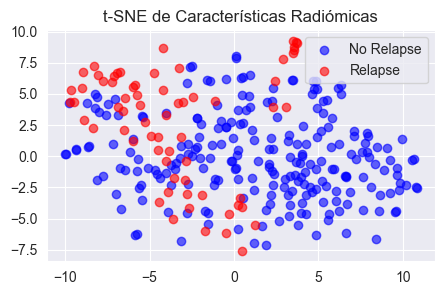

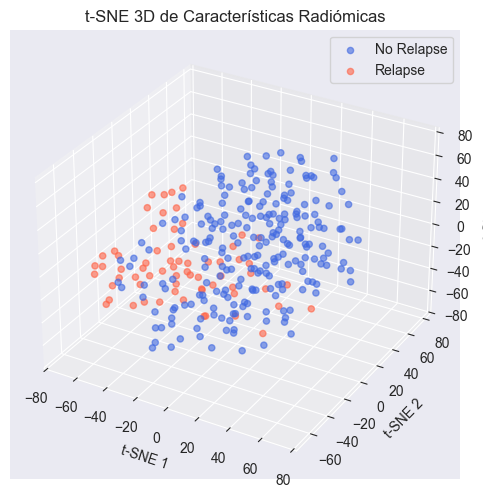

In [481]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# 📌 Cargar datos
X = pd.read_csv("data_to_use.csv")

# 🎯 Extraer etiquetas y eliminar del dataset antes de t-SNE
y = X['group_name']  # Ya es 0 o 1
X = X.drop(columns=['group_name'])  # Quitar la columna de etiquetas

# 📌 0. Comprobar si hay NaN y eliminarlos (o imputarlos)
simple_imputer = SimpleImputer(strategy='mean')
X_imputed = simple_imputer.fit_transform(X)

# 📌 1. Normalización de las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# # 📌 2. Filtrar características con varianza baja (evita ruido)
# selector = VarianceThreshold(threshold=0.01)  # Filtra columnas con varianza muy baja
# X_filtered = selector.fit_transform(X_scaled)

# 📌 3. Reducir la dimensión con PCA antes de t-SNE
# pca = PCA(30)  # Se reduce a 30 dimensiones antes de t-SNE
# X_pca = pca.fit_transform(X_filtered)

# 📌 4. Aplicar t-SNE
X_embedded = TSNE(n_components=2, perplexity=50, random_state=42).fit_transform(X_scaled)

# 📊 5. Graficar los resultados
plt.figure(figsize=(5, 3))
plt.scatter(X_embedded[y == 0, 0], X_embedded[y == 0, 1], c='blue', label='No Relapse', alpha=0.6)
plt.scatter(X_embedded[y == 1, 0], X_embedded[y == 1, 1], c='red', label='Relapse', alpha=0.6)
plt.title("t-SNE de Características Radiómicas")
plt.legend()
plt.show()

X_embedded_3d = TSNE(n_components=3, perplexity=50, random_state=42).fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_embedded_3d[y == 0, 0], X_embedded_3d[y == 0, 1], X_embedded_3d[y == 0, 2], c='royalblue', label='No Relapse', alpha=0.6)
ax.scatter(X_embedded_3d[y == 1, 0], X_embedded_3d[y == 1, 1], X_embedded_3d[y == 1, 2], c='tomato', label='Relapse', alpha=0.6)
ax.set_title("t-SNE 3D de Características Radiómicas")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
ax.legend()
plt.tight_layout()
plt.show()



In [482]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import RobustScaler
# from src.processing import Processing

# # Cargar datos
# dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NEW_FIXED, all_features=False)
# dataclass.read()
# df = dataclass.df

# # Filtrar ratones problemáticos
# df = df[~df["m_id"].isin([1258, 1260, 1261, 1297, 1299, 1359, 1360, 1361])]

# # Features por fold (ya sin "slope"/"rolling_mean")
# features_per_fold = {
#     0: [
#         # "exponential_glszm_SizeZoneNonUniformity",
#         # "wavelet-LH_firstorder_Kurtosis",
#         # "log-sigma-2-0-mm-3D_glcm_ClusterShade",
#         # "log-sigma-1-0-mm-3D_glrlm_LongRunHighGrayLevelEmphasis",
#         # "original_glcm_MCC",
#         # "wavelet-LL_gldm_LargeDependenceEmphasis",
#         # "wavelet-LH_glrlm_LongRunHighGrayLevelEmphasis",
#         # "wavelet-LL_glszm_LargeAreaLowGrayLevelEmphasis",
#         # "square_ngtdm_Coarseness",
#         # "wavelet-LH_gldm_DependenceVariance"
#         "original_firstorder_Kurtosis",
#         "original_glszm_GrayLevelNonUniformityNormalized",
#         "original_glcm_ClusterProminence",
#         "original_gldm_DependenceEntropy",
#         "original_firstorder_Skewness",
#         "original_shape2D_Elongation",
#         "original_glrlm_RunEntropy",
#         "original_glrlm_ShortRunHighGrayLevelEmphasis",
#         "original_glrlm_HighGrayLevelRunEmphasis"
#     ],
#     1: [
#         # "log-sigma-3-0-mm-3D_glszm_ZoneEntropy",
#         # "original_glszm_ZoneEntropy",
#         # "wavelet-LH_gldm_DependenceVariance",
#         # "wavelet-LL_gldm_DependenceVariance",
#         # "gradient_firstorder_Maximum",
#         # "wavelet-LH_gldm_DependenceVariance",
#         # "wavelet-LL_gldm_LargeDependenceEmphasis",
#         # "original_firstorder_90Percentile",
#         # "original_gldm_LargeDependenceEmphasis",
#         # "original_glcm_MCC"
#     ]
# }

# # Escalar todas las features involucradas
# all_features = set(f for features in features_per_fold.values() for f in features)
# # scaler = RobustScaler()
# # df[list(all_features)] = scaler.fit_transform(df[list(all_features)])

# # Colores por grupo
# colors = {1: 'green', 0: 'red'}

# # Crear un plot individual por feature
# for fold, features in features_per_fold.items():
#     for feature in features:
#         plt.figure(figsize=(6, 3))

#         # Filtrar outliers
#         # Q1 = df[feature].quantile(0.25)
#         # Q3 = df[feature].quantile(0.75)
#         # IQR = Q3 - Q1
#         # lower_bound = Q1 - 1.5 * IQR
#         # upper_bound = Q3 + 1.5 * IQR
#         # df_clean = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

#         # Agrupar y suavizar
#         df_grouped = df.groupby(["group_name", "day_of_study"])[feature].agg(['mean']).reset_index()
#         df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

#         # Graficar por grupo
#         for group in df_grouped["group_name"].unique():
#             subset = df_grouped[df_grouped["group_name"] == group]
#             if group == 1:
#                 label = "Cured"
#             else:
#                 label = "Relapse"
#             plt.plot(subset["day_of_study"], subset["smoothed_mean"], '-o',
#                      linewidth=2, markersize=4, color=colors[group], label=f"{label}")

#         plt.xlabel("Study Day")
#         plt.ylabel("Standardized Value")
#         plt.title(f"{feature}", fontsize=10)
#         plt.xticks(np.arange(10, df["day_of_study"].max() + 1, 5))
#         plt.grid(True, linestyle='--', alpha=0.6)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()  # O usa plt.savefig(f"output_final/hyp1/imgs/fold_{fold}_{feature}.png")


In [483]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from src.processing import Processing

# # Cargar datos
# dataclass = Processing(source_path=config.RADIOMICS_FINAL_FEATURES_NEW_FIXED, all_features=False)
# dataclass.read()
# df = dataclass.df

# # Filtrar ratones problemáticos
# df = df[~df["m_id"].isin([1258, 1260, 1261, 1297, 1299, 1359, 1360, 1361])]

# # Features por fold (ya sin "slope"/"rolling_mean")
# features_per_fold = {
#     0: [
#         "original_firstorder_Kurtosis",
#         "original_glszm_GrayLevelNonUniformityNormalized",
#         "square_glcm_ClusterProminence",
#         "original_gldm_DependenceEntropy",
#         "original_firstorder_Skewness",
#         "original_shape2D_Elongation",
#         "original_glrlm_RunEntropy",
#         "original_glrlm_ShortRunHighGrayLevelEmphasis",
#         "original_glrlm_HighGrayLevelRunEmphasis"
#     ],
#     1: [
#         # No hay features activados para fold 1 en tu snippet
#     ]
# }

# # Colores por grupo
# colors = {1: 'green', 0: 'red'}

# # Crear un plot individual por feature
# for fold, features in features_per_fold.items():
#     for feature in features:
#         plt.figure(figsize=(6, 3))

#         # Filtrar outliers
#         Q1 = df[feature].quantile(0.25)
#         Q3 = df[feature].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df_clean = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

#         # Agrupar y suavizar
#         df_grouped = df_clean.groupby(["group_name", "day_of_study"])[feature].agg(['mean']).reset_index()
#         df_grouped["smoothed_mean"] = df_grouped.groupby("group_name")["mean"].transform(lambda x: x.ewm(span=3, adjust=False).mean())

#         # Graficar por grupo
#         for group in df_grouped["group_name"].unique():
#             subset = df_grouped[df_grouped["group_name"] == group]
#             label = "Cured" if group == 1 else "Relapse"
#             plt.plot(subset["day_of_study"], subset["smoothed_mean"], '-o',
#                      linewidth=2, markersize=4, color=colors[group], label=f"{label}")

#         plt.xlabel("Study Day")
#         plt.ylabel("Feature Value")
#         plt.title(f"{feature}", fontsize=10)
#         plt.xticks(np.arange(10, df["day_of_study"].max() + 1, 5))
#         plt.grid(True, linestyle='--', alpha=0.6)
#         plt.legend()
#         plt.tight_layout()
#         plt.show()  # O guarda con plt.savefig(...)


In [484]:
import os
import pandas as pd

import numpy as np

def resumen_dias(dias_str):
    dias = [int(d) for d in dias_str.strip("[]").split() if d.isdigit()]
    if len(dias) == 0:
        return "-"
    dias = sorted(dias)
    return f"{min(dias)}–{max(dias)}"


# Ruta base donde están los folds
base_path = "output_final1/hyp1/baseline/expanding_window_split"
NUM_FOLDS = 10  # o los que tengas


# Lista para almacenar cada fila como diccionario
rows = []

# Iterar sobre cada fold
for i in range(NUM_FOLDS):
    metrics_path = os.path.join(base_path, f"fold_{i}", "metrics.csv")
    if os.path.exists(metrics_path):
        try:
            df = pd.read_csv(metrics_path)
            row = df.loc[0].to_dict()

            # Calcular Specificity si se puede
            tn, fp = row["true_negatives"], row["false_positives"]
            specificity = tn / (tn + fp) if (tn + fp) > 0 else None

            ppv = row["precision"]
            npv = tn / (tn + row["false_negatives"]) if (tn + row["false_negatives"]) > 0 else None

            rows.append({
                "Fold": i,
                "Train Days (min–max)": resumen_dias(row["days_of_study_in_train"]),
                "Test Days (min–max)": resumen_dias(row["days_of_study_in_test"]),
                "Accuracy": round(row["accuracy"], 4),
                "F1-macro": round(row["f1_macro"], 4),
                "F1-weighted": round(row["f1_weighted"], 4),
                "Recall (Sensitivity)": round(row["recall"], 4),
                "Specificity": round(specificity, 4) if specificity is not None else None,
                "ROC AUC": round(row["roc_auc"], 4),
                "Precision": round(row["precision"], 4),
                "TP": row["true_positives"],
                "TN": row["true_negatives"],
                "FP": row["false_positives"],
                "FN": row["false_negatives"],
                "PPV": round(ppv, 4) if ppv is not None else None,
                "NPV": round(npv, 4) if npv is not None else None,
            })

        except Exception as e:
            print(f"Error en fold {i}: {e}")
    else:
        print(f"Fold {i} no encontrado.")

# Crear DataFrame resumen
results_df = pd.DataFrame(rows)

# Mostrar
print(results_df)

# (Opcional) Exportar a CSV o LaTeX
results_df.to_csv("tabla_metrics_folds.csv", index=False)
# print(results_df.to_latex(index=False))  # para Overleaf


   Fold Train Days (min–max) Test Days (min–max)  Accuracy  F1-macro  \
0     0                 9–15               15–17    0.6296    0.6165   
1     1                 9–17               17–21    0.7037    0.6824   
2     2                 9–21               21–23    0.8519    0.8224   
3     3                 9–23               23–25    0.8148    0.7970   
4     4                 9–25               25–27    0.9259    0.9206   
5     5                 9–27               27–31    0.9259    0.8773   
6     6                 9–31               31–33    0.9630    0.9179   
7     7                 9–33               35–37    1.0000    1.0000   
8     8                 9–37               37–41    0.9630    0.9179   
9     9                 9–41               41–49    0.9630    0.8235   

   F1-weighted  Recall (Sensitivity)  Specificity  ROC AUC  Precision  TP  TN  \
0       0.6349                0.6000       0.6471   0.5647     0.5000   6  11   
1       0.7098                0.6667       0.

No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_0\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_1\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_2\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_3\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_4\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_5\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_6\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_7\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_8\summary_metrics.csv
No encontrado: output_final/hyp1/baseline/expanding_window_split\fold_9\summary_metrics.csv


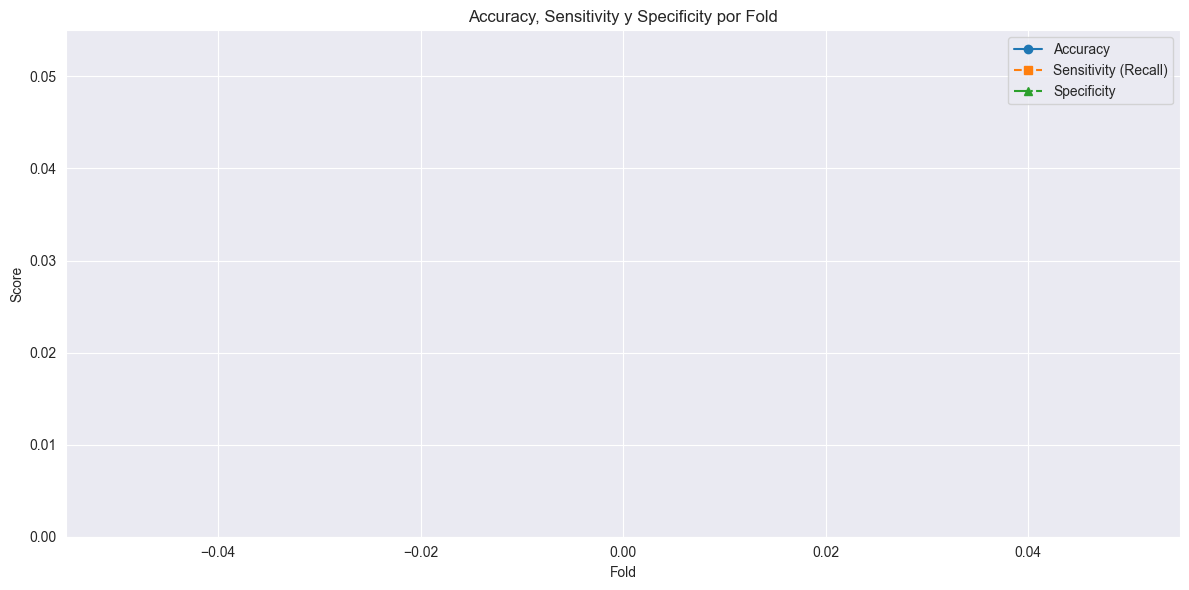

In [485]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ruta base donde están los folds
base_path = "output_final/hyp1/baseline/expanding_window_split"

# Listas para guardar resultados
folds = []
accuracies = []
sensitivities = []
specificities = []
roc_auc = []

# Iterar sobre los folders
for i in range(10):  # Ajusta según el total de folds
    metrics_path = os.path.join(base_path, f"fold_{i}", "summary_metrics.csv")
    if os.path.exists(metrics_path):
        df = pd.read_csv(metrics_path)
        try:
            acc = df.loc[0, "accuracy"]
            recall = df.loc[0, "recall"]
            tn = df.loc[0, "true_negatives"]
            fp = df.loc[0, "false_positives"]
            auc_roc = df.loc[0, "roc_auc"]

            # Verificamos que se puedan calcular correctamente
            if pd.isna(recall) or recall == 0:
                print(f"Fold {i}: Recall no definido, se omite.")
                continue

            if (tn + fp) == 0 or tn == 0:
                print(f"Fold {i}: No hay negativos, no se puede calcular especificidad. Se omite.")
                continue

            specificity = tn / (tn + fp)

            # Agregamos resultados
            folds.append(i)
            accuracies.append(acc)
            sensitivities.append(recall)
            specificities.append(specificity)
            roc_auc.append(auc_roc)

        except Exception as e:
            print(f"Error en fold {i}: {e}")
            continue
    else:
        print(f"No encontrado: {metrics_path}")

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(folds, accuracies, marker='o', linestyle='-', label="Accuracy")
plt.plot(folds, sensitivities, marker='s', linestyle='--', label="Sensitivity (Recall)")
plt.plot(folds, specificities, marker='^', linestyle='-.', label="Specificity")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Accuracy, Sensitivity y Specificity por Fold")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



## 0-Baseline All Features

In [486]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_all_features/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')



# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score Macro: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count          well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     7 [14, 18, 20, 22, 24, 24, 24]                    2             [7, 7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [8, 8, 10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 14]

===== Fold 3 =====
 m_id_1263  true_label  well_predicted_count                                            

## 1-Baseline All Features Oversampling

In [487]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_all_features_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count         well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     7 [7, 18, 20, 22, 24, 24, 24]                    2            [7, 14]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [8, 8, 10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 14]

===== Fold 3 =====
 m_id_1263  true_label  well_predicted_count                                              

## 2-Baseline All Features Oversampling No Control Cases

In [488]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)
f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                                              well_predicted_days  bad_predicted_count                               bad_predicted_days
      1263           0                    44 [11, 14, 14, 14, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 25, 25, 25, 27, 27, 29, 29, 31, 33, 35, 35, 37, 37, 37, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47]                   12 [11, 11, 23, 23, 25, 29, 31, 31, 33, 33, 39, 47]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                                              well_predicted_days  bad_predicted_count bad_predicted_days
      1264           0                    40 [11, 11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 25, 25, 25, 

## 3-Var HC Features Oversampling No Control Cases

In [489]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                                                      well_predicted_days  bad_predicted_count                       bad_predicted_days
      1263           0                    46 [11, 14, 14, 14, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 25, 25, 25, 27, 27, 29, 29, 29, 31, 33, 33, 33, 35, 35, 37, 37, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47]                   10 [11, 11, 17, 23, 25, 31, 31, 37, 39, 47]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                                          well_predicted_days  bad_predicted_count bad_predicted_days
      1264           0                    39 [11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 25, 25, 25, 27, 27, 29, 

## 4-Var HC SF Features Oversampling No Control Cases

In [490]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_sf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')




===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                                                                  well_predicted_days  bad_predicted_count           bad_predicted_days
      1263           0                    49 [11, 14, 14, 14, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 25, 25, 25, 27, 27, 29, 29, 29, 31, 31, 33, 33, 33, 35, 35, 37, 37, 37, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47]                    7 [11, 11, 23, 25, 31, 39, 47]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                                          well_predicted_days  bad_predicted_count bad_predicted_days
      1264           0                    39 [11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 25, 25, 25, 27, 27, 

In [491]:
# Concatenar resultados de todos los folds
all_mice = pd.concat(fold_results.values(), ignore_index=True)

# Encuentra todas las columnas que comienzan con "m_id_"
id_cols = [col for col in all_mice.columns if col.startswith("m_id_")]

# Crea una nueva columna "mouse_id" tomando el primer valor no nulo en las columnas de ID
all_mice["mouse_id"] = all_mice[id_cols].bfill(axis=1).iloc[:, 0]

# Luego eliminamos las columnas viejas
all_mice.drop(columns=id_cols, inplace=True)

# Calcular total de predicciones y accuracy
all_mice["total_preds"] = all_mice["well_predicted_count"] + all_mice["bad_predicted_count"]
all_mice["accuracy"] = all_mice["well_predicted_count"] / all_mice["total_preds"]

# Mapear clase 0,1 a texto
label_map = {0: "Relapse", 1: "Cured"}
all_mice["class_label"] = all_mice["true_label"].map(label_map)

# Ahora ya tienes todo limpio en 'all_mice'
(all_mice)


,true_label,well_predicted_count,well_predicted_days,bad_predicted_count,bad_predicted_days,mouse_id,total_preds,accuracy,class_label
0,0,49,"[11, 14, 14, 14, 17, 17, 17, 19, 19, 19, 21, 2...",7,"[11, 11, 23, 25, 31, 39, 47]",1263.0,56,0.875000,Relapse
1,0,39,"[11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 2...",4,"[11, 11, 27, 35]",1264.0,43,0.906977,Relapse
2,0,42,"[10, 10, 10, 15, 15, 15, 17, 17, 19, 19, 19, 2...",1,[23],1270.0,43,0.976744,Relapse
3,1,12,"[19, 23, 25, 25, 27, 31, 33, 35, 37, 39, 41, 45]",9,"[11, 15, 17, 17, 19, 23, 27, 29, 33]",1276.0,21,0.571429,Cured
4,1,7,"[17, 17, 19, 21, 21, 23, 27]",5,"[10, 13, 15, 19, 23]",1281.0,12,0.583333,Cured
5,1,6,"[10, 17, 19, 21, 23, 27]",2,"[13, 15]",1284.0,8,0.750000,Cured
6,1,5,"[9, 17, 23, 27, 27]",12,"[15, 15, 17, 19, 19, 21, 21, 23, 25, 25, 29, 31]",1285.0,17,0.294118,Cured
7,0,42,"[18, 19, 19, 19, 21, 21, 21, 22, 23, 23, 23, 2...",5,"[11, 11, 11, 17, 20]",1380.0,47,0.893617,Relapse
8,1,4,"[11, 25, 27, 29]",4,"[17, 19, 21, 23]",1382.0,8,0.500000,Cured
9,0,34,"[11, 17, 17, 19, 19, 25, 25, 27, 27, 29, 29, 3...",9,"[11, 11, 17, 21, 21, 23, 23, 31, 41]",1383.0,43,0.790698,Relapse


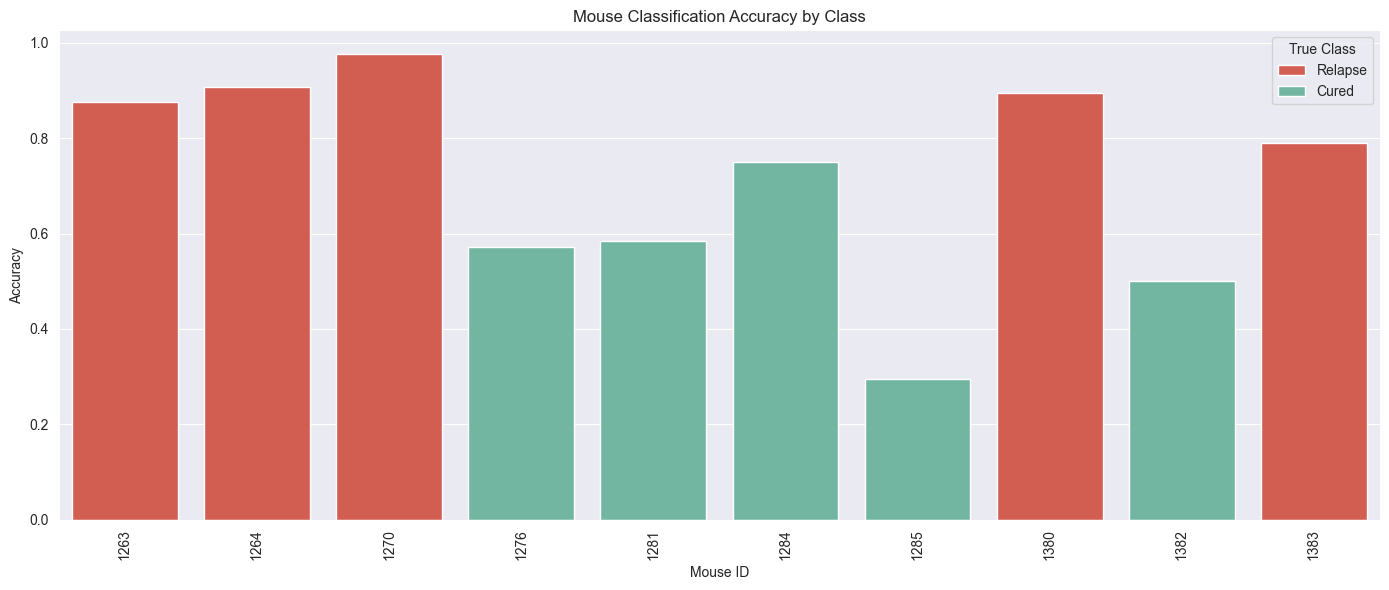

In [492]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

# Convertir "mouse_id" a int
all_mice["mouse_id"] = all_mice["mouse_id"].astype(int)

# Definir nueva paleta personalizada
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

plt.figure(figsize=(14, 6))
sns.barplot(
    data=all_mice,
    x="mouse_id",
    y="accuracy",
    hue="class_label",
    palette=palette  # 👈 colores nuevos
)
plt.xticks(rotation=90)
plt.title("Mouse Classification Accuracy by Class")
plt.ylabel("Accuracy")
plt.xlabel("Mouse ID")
plt.legend(title="True Class")
plt.tight_layout()
plt.show()




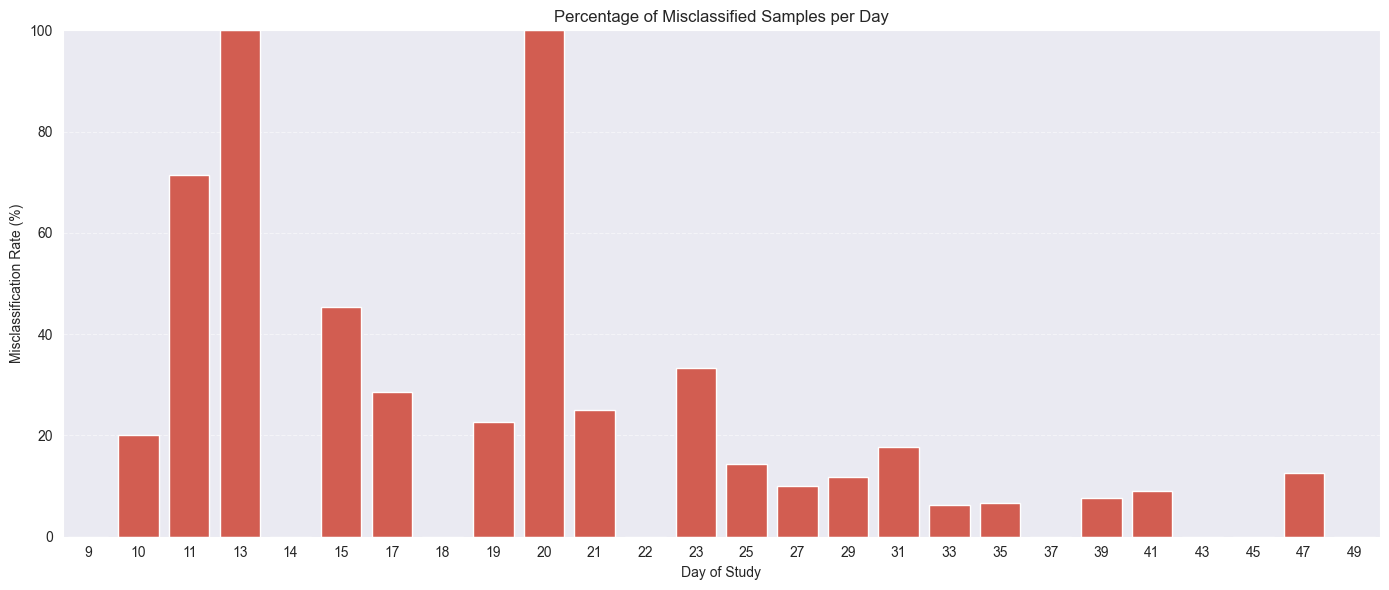

In [493]:
# Crear una lista con todas las predicciones (malas y buenas)
day_stats = []

for idx, row in all_mice.iterrows():
    mouse_id = int(row["mouse_id"])
    
    for day in row["bad_predicted_days"]:
        day_stats.append({
            "Day": day,
            "Type": "Incorrect"
        })
        
    for day in row["well_predicted_days"]:
        day_stats.append({
            "Day": day,
            "Type": "Correct"
        })

day_stats_df = pd.DataFrame(day_stats)

# Contar el número de predicciones correctas e incorrectas por día
counts = (
    day_stats_df.groupby(["Day", "Type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Asegurar que hay columnas para ambas clases
if "Correct" not in counts:
    counts["Correct"] = 0
if "Incorrect" not in counts:
    counts["Incorrect"] = 0

# Calcular el porcentaje de errores por día
counts["Error Rate (%)"] = 100 * counts["Incorrect"] / (counts["Correct"] + counts["Incorrect"])


plt.figure(figsize=(14, 6))
sns.barplot(data=counts, x="Day", y="Error Rate (%)", color="#e74c3c")

plt.title("Percentage of Misclassified Samples per Day")
plt.ylabel("Misclassification Rate (%)")
plt.xlabel("Day of Study")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



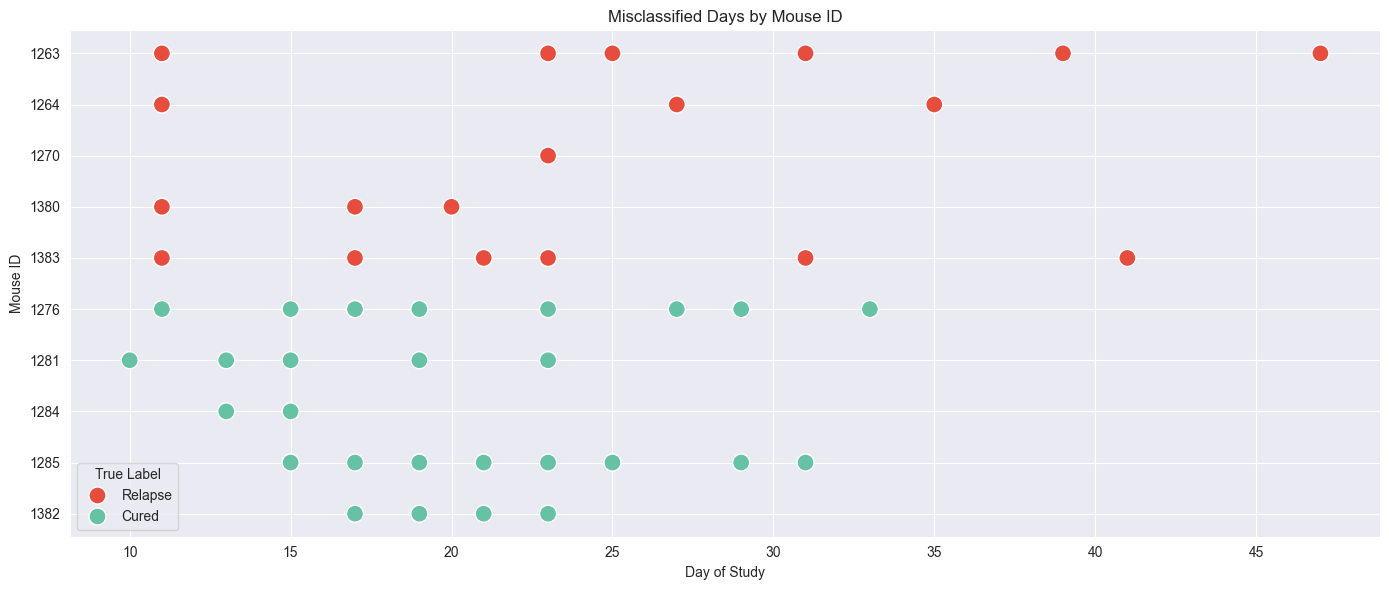

In [494]:
# Expandir los días mal clasificados
error_days = []
for idx, row in all_mice.iterrows():
    for day in row["bad_predicted_days"]:
        error_days.append({
            "Mouse ID": int(row["mouse_id"]),
            "Day of Study": day,
            "True Label": row["class_label"]
        })

error_days_df = pd.DataFrame(error_days)

# 🛠️ Ordenar primero los mouse por "Relapse" arriba, "Cured" abajo
mouse_order = (
    error_days_df
    .drop_duplicates("Mouse ID")
    .sort_values("True Label", ascending=False)["Mouse ID"]
    .astype(str)
    .tolist()
)

# 🛠️ Convertir "Mouse ID" a categoría ordenada
error_days_df["Mouse ID"] = error_days_df["Mouse ID"].astype(str)
error_days_df["Mouse ID"] = pd.Categorical(error_days_df["Mouse ID"], categories=mouse_order, ordered=True)

# Plot
sns.set_style("darkgrid")
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

plt.figure(figsize=(14, 6))  # más altura
sns.scatterplot(
    data=error_days_df,
    x="Day of Study",
    y="Mouse ID",  # ahora ya está ordenado
    hue="True Label",
    palette=palette,
    hue_order=["Relapse", "Cured"],
    s=150,  # tamaño de los puntos
)

plt.title("Misclassified Days by Mouse ID")
plt.xlabel("Day of Study")
plt.ylabel("Mouse ID")
plt.tight_layout()
plt.show()


In [495]:
# # Juntar días correctos e incorrectos
# days_data = []

# for idx, row in all_mice.iterrows():
#     for day in row["bad_predicted_days"]:
#         days_data.append({
#             "Mouse ID": row["mouse_id"],
#             "Day": day,
#             "Correct": "Incorrect",
#             "True Label": row["class_label"]
#         })
#     for day in row["well_predicted_days"]:
#         days_data.append({
#             "Mouse ID": row["mouse_id"],
#             "Day": day,
#             "Correct": "Correct",
#             "True Label": row["class_label"]
#         })

# days_df = pd.DataFrame(days_data)

# plt.figure(figsize=(10, 6))
# sns.boxplot(
#     data=days_df,
#     x="Correct",
#     y="Day",
#     hue="True Label",
#     palette="Set2"
# )
# plt.title("Distribución de días bien vs mal clasificados")
# plt.ylabel("Día del estudio")
# plt.xlabel("")
# plt.tight_layout()
# plt.show()


In [496]:
# heatmap_data = all_mice[["mouse_id", "well_predicted_count", "bad_predicted_count"]]
# heatmap_data = heatmap_data.set_index("mouse_id")

# plt.figure(figsize=(12, 6))
# sns.heatmap(
#     heatmap_data,
#     annot=True,
#     fmt="d",
#     cmap="coolwarm",
#     cbar_kws={"label": "Cantidad"},
#     linewidths=0.5
# )
# plt.title("Número de aciertos vs errores por ratón")
# plt.ylabel("Mouse ID")
# plt.tight_layout()
# plt.show()


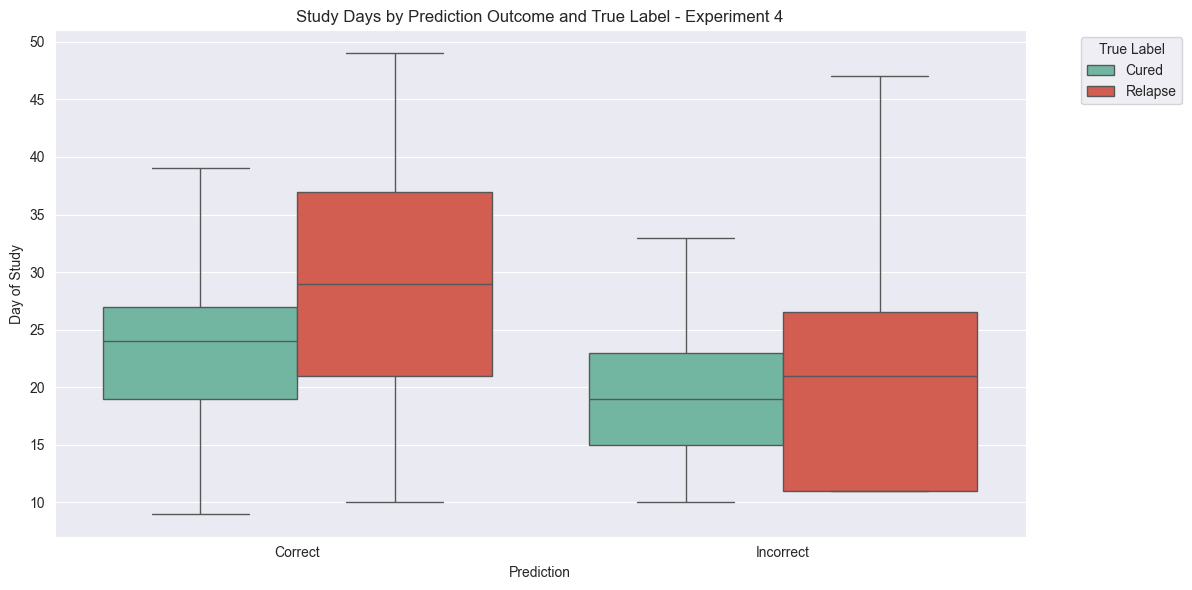

In [497]:
def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    # Mapeo de etiquetas numéricas a texto
    label_map = {0: "Relapse", 1: "Cured"}

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = label_map[row["true_label"]]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    sns.set_style("darkgrid")
    plt.figure(figsize=(12, 6))

    # Definir la paleta de colores y el orden
    palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}
    hue_order = ["Cured", "Relapse"]

    ax = sns.boxplot(
        data=df_plot, 
        x="Prediction", 
        y="Day", 
        hue="True Label", 
        palette=palette, 
        hue_order=hue_order,
        fliersize=0
    )

    # Ajustar leyenda
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, labels, title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Títulos y ejes
    plt.title("Study Days by Prediction Outcome and True Label - Experiment 4")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.tight_layout()

    # Guardar o mostrar
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()


# Luego puedes llamar la función normalmente:
plot_prediction_days(fold_results)



===== Global Metrics =====
Accuracy: 0.8197
ROC AUC: 0.7097
Sensitivity (Recall/TPR): 0.5000
Specificity (TNR): 0.9194
PPV (Precision): 0.6591
NPV: 0.8550
F1 Score (Weighted): 0.8106
F1 Score: 0.7273

## 5-LF Var HC SF Features Oversampling No Control Cases

In [498]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_lf_sf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1263  true_label  well_predicted_count                                                                                                                                              well_predicted_days  bad_predicted_count                                               bad_predicted_days
      1263           0                    40 [11, 11, 14, 14, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 29, 29, 31, 33, 35, 35, 37, 37, 37, 39, 39, 39, 41, 41, 41, 43, 43, 43, 45, 45, 45, 45, 47, 47, 47, 47]                   16 [11, 14, 23, 23, 23, 25, 25, 25, 25, 27, 27, 29, 31, 31, 33, 33]

===== Fold 1 =====
 m_id_1264  true_label  well_predicted_count                                                                                                                                                      well_predicted_days  bad_predicted_count bad_predicted_days
      1264           0                    42 [11, 11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 19, 21, 21, 21, 23, 23, 23, 25, 

## 6-Heuristic LF Var HC SF Features Oversampling No Control Cases

In [499]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_heuristic_lf_sf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count                                      well_predicted_days  bad_predicted_count           bad_predicted_days
      1276           1                    14 [23, 23, 25, 25, 27, 27, 31, 33, 33, 35, 37, 39, 41, 45]                    7 [11, 15, 17, 17, 19, 19, 29]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     8 [17, 19, 19, 21, 21, 23, 23, 27]                    4   [10, 13, 15, 17]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count          well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     7 [10, 15, 17, 19, 21, 23, 27]                    1               [13]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                      bad_predicted_days
      1285

In [500]:
# Concatenar resultados de todos los folds
all_mice = pd.concat(fold_results.values(), ignore_index=True)

# Encuentra todas las columnas que comienzan con "m_id_"
id_cols = [col for col in all_mice.columns if col.startswith("m_id_")]

# Crea una nueva columna "mouse_id" tomando el primer valor no nulo en las columnas de ID
all_mice["mouse_id"] = all_mice[id_cols].bfill(axis=1).iloc[:, 0]

# Luego eliminamos las columnas viejas
all_mice.drop(columns=id_cols, inplace=True)

# Calcular total de predicciones y accuracy
all_mice["total_preds"] = all_mice["well_predicted_count"] + all_mice["bad_predicted_count"]
all_mice["accuracy"] = all_mice["well_predicted_count"] / all_mice["total_preds"]

# Mapear clase 0,1 a texto
label_map = {0: "Relapse", 1: "Cured"}
all_mice["class_label"] = all_mice["true_label"].map(label_map)

# Ahora ya tienes todo limpio en 'all_mice'
(all_mice)

,true_label,well_predicted_count,well_predicted_days,bad_predicted_count,bad_predicted_days,mouse_id,total_preds,accuracy,class_label
0,1,14,"[23, 23, 25, 25, 27, 27, 31, 33, 33, 35, 37, 3...",7.0,"[11, 15, 17, 17, 19, 19, 29]",1276.0,21.0,0.666667,Cured
1,1,8,"[17, 19, 19, 21, 21, 23, 23, 27]",4.0,"[10, 13, 15, 17]",1281.0,12.0,0.666667,Cured
2,1,7,"[10, 15, 17, 19, 21, 23, 27]",1.0,[13],1284.0,8.0,0.875000,Cured
3,1,3,"[25, 25, 27]",14.0,"[15, 15, 17, 17, 19, 19, 21, 21, 23, 23, 27, 2...",1285.0,17.0,0.176471,Cured
4,1,2,"[27, 29]",6.0,"[11, 17, 19, 21, 23, 25]",1382.0,8.0,0.250000,Cured
5,0,46,"[11, 14, 14, 17, 17, 17, 19, 19, 19, 21, 21, 2...",10.0,"[11, 11, 14, 25, 25, 27, 29, 31, 31, 39]",1263.0,56.0,0.821429,Relapse
6,0,40,"[11, 15, 15, 15, 17, 17, 17, 17, 19, 19, 21, 2...",3.0,"[11, 11, 19]",1264.0,43.0,0.930233,Relapse
7,0,43,"[10, 10, 10, 15, 15, 15, 17, 17, 19, 19, 19, 2...",0.0,[],1270.0,43.0,1.000000,Relapse
8,0,42,"[11, 11, 19, 20, 21, 21, 21, 22, 23, 23, 23, 2...",5.0,"[11, 17, 18, 19, 19]",1380.0,47.0,0.893617,Relapse
9,0,34,"[11, 11, 17, 17, 19, 19, 21, 25, 27, 29, 31, 3...",9.0,"[11, 17, 21, 23, 23, 25, 27, 29, 31]",1383.0,43.0,0.790698,Relapse


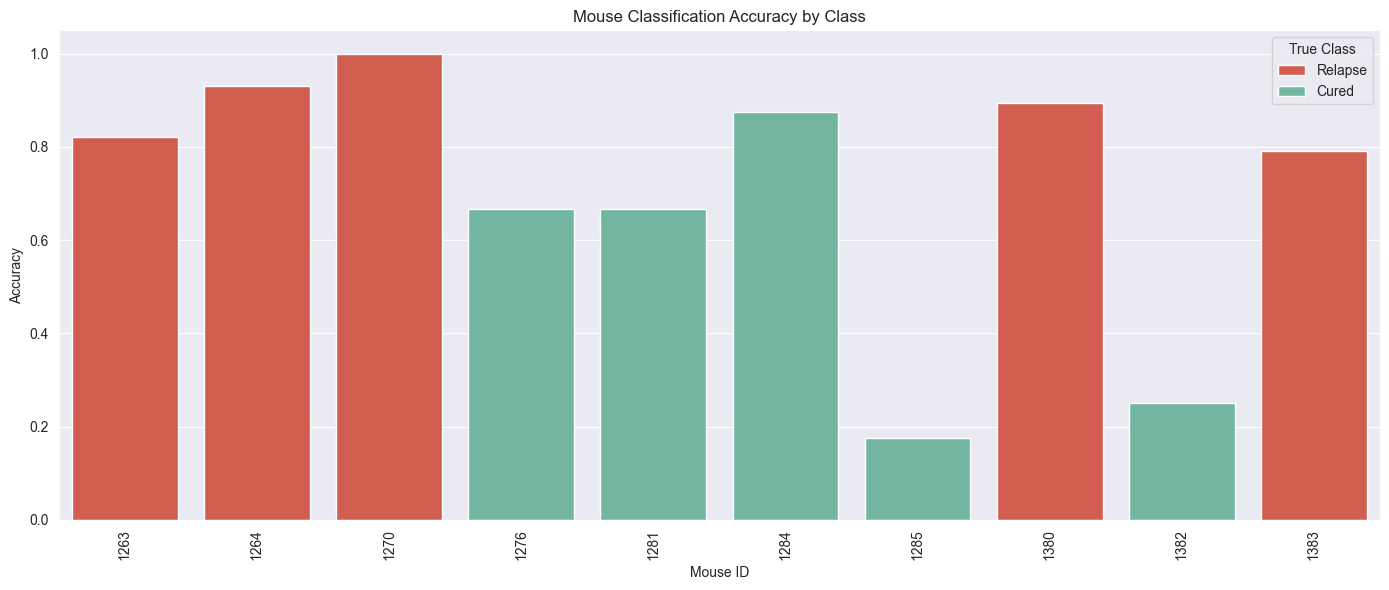

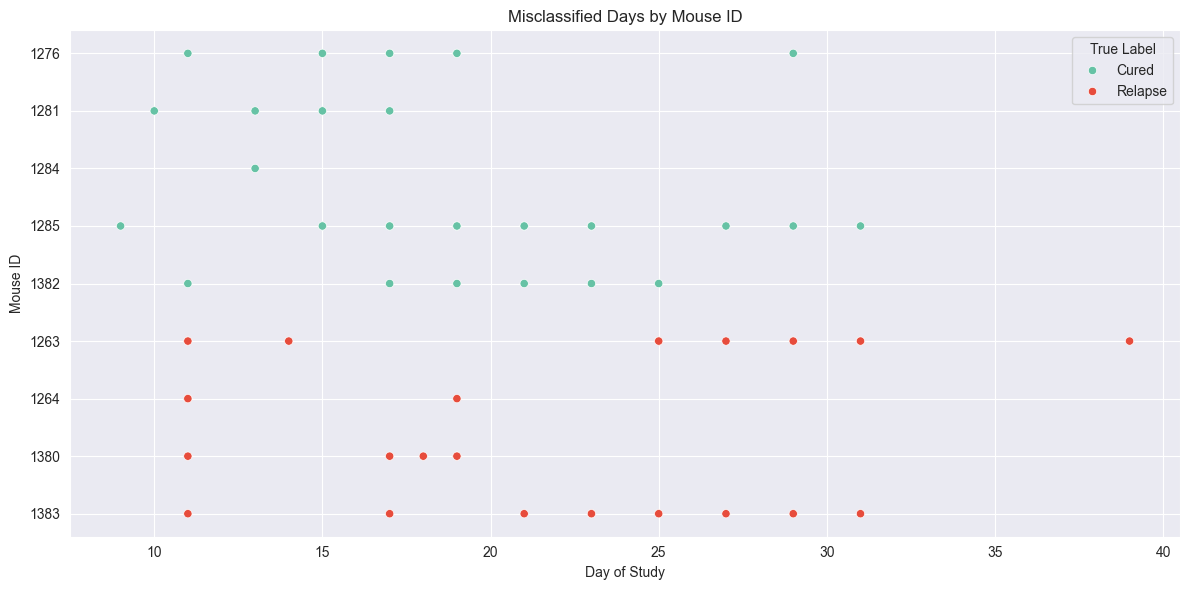

In [501]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

# Convertir "mouse_id" a int
all_mice["mouse_id"] = all_mice["mouse_id"].astype(int)

# Definir nueva paleta personalizada
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

plt.figure(figsize=(14, 6))
sns.barplot(
    data=all_mice,
    x="mouse_id",
    y="accuracy",
    hue="class_label",
    palette=palette  # 👈 colores nuevos
)
plt.xticks(rotation=90)
plt.title("Mouse Classification Accuracy by Class")
plt.ylabel("Accuracy")
plt.xlabel("Mouse ID")
plt.legend(title="True Class")
plt.tight_layout()
plt.show()


# print(all_mice)
# Expandir para hacer un punto por cada día fallado
error_days = []
for idx, row in all_mice.iterrows():
    for day in row["bad_predicted_days"]:
        error_days.append({
            "Mouse ID": int(row["mouse_id"]),
            "Day of Study": day,
            "True Label": row["class_label"]
        })

error_days_df = pd.DataFrame(error_days)
sns.set_style("darkgrid")
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=error_days_df,
    x="Day of Study",
    y=error_days_df["Mouse ID"].astype(str),  # 👈 pasamos a texto para que los trate como categorías
    hue="True Label",
    palette=palette
)
# English
plt.title("Misclassified Days by Mouse ID")
plt.xlabel("Day of Study")
plt.ylabel("Mouse ID")
plt.tight_layout()
plt.show()


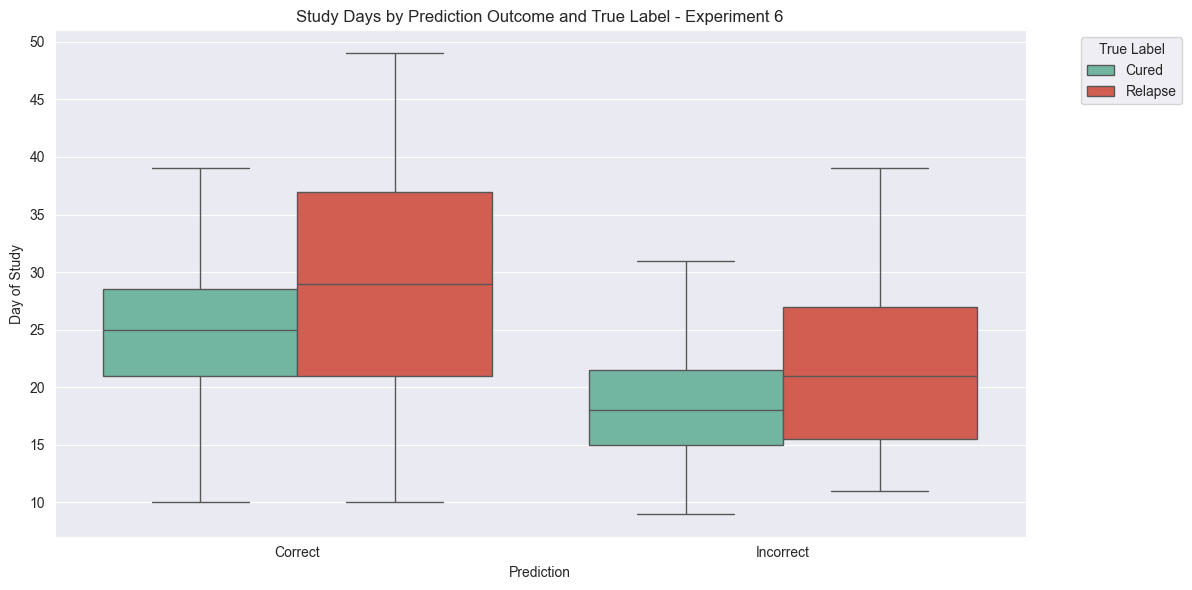

In [502]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    # Mapeo de etiquetas numéricas a texto
    label_map = {0: "Relapse", 1: "Cured"}

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = label_map[row["true_label"]]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)
    
    sns.set_style("darkgrid")
    # Crear el gráfico
    plt.figure(figsize=(12, 6))

    ax = sns.boxplot(
        data=df_plot, 
        x="Prediction", 
        y="Day", 
        hue="True Label", 
        palette=palette, 
        fliersize=0
    )

    # Ajustar leyenda
    handles, labels = ax.get_legend_handles_labels()
    n_labels = len(df_plot["True Label"].unique())
    plt.legend(handles[:n_labels], labels[:n_labels], title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Títulos y ejes
    plt.title("Study Days by Prediction Outcome and True Label - Experiment 6")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.tight_layout()

    # Guardar o mostrar
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

# Luego puedes llamar la función normalmente:
plot_prediction_days(fold_results)

## 7-Heuristic LF Var HC NOSF Features Oversampling No Control Cases

In [503]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_heuristic_lf_NOsf_var_hc_oversample/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')



===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count                                      well_predicted_days  bad_predicted_count           bad_predicted_days
      1276           1                    14 [23, 23, 25, 25, 27, 27, 31, 33, 33, 35, 37, 39, 41, 45]                    7 [11, 15, 17, 17, 19, 19, 29]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                  well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     9 [17, 17, 19, 19, 21, 21, 23, 23, 27]                    3       [10, 13, 15]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count  well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     5 [10, 19, 21, 23, 27]                    3       [13, 15, 17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                  bad_predicted_days
      1285           1

## 8-Heuristic LF Var HC NOSF Features Oversampling No Control Cases again HEURISTIC

In [504]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_heuristic_lf_NOsf_var_hc_oversample_reduce_again_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count                              well_predicted_days  bad_predicted_count                   bad_predicted_days
      1276           1                    12 [23, 23, 25, 25, 27, 31, 33, 33, 37, 39, 41, 45]                    9 [11, 15, 17, 17, 19, 19, 27, 29, 35]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     8 [17, 17, 19, 19, 21, 21, 23, 27]                    4   [10, 13, 15, 23]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count      well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     6 [10, 17, 19, 21, 23, 27]                    2           [13, 15]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                  bad_predicted_days
      1285           1

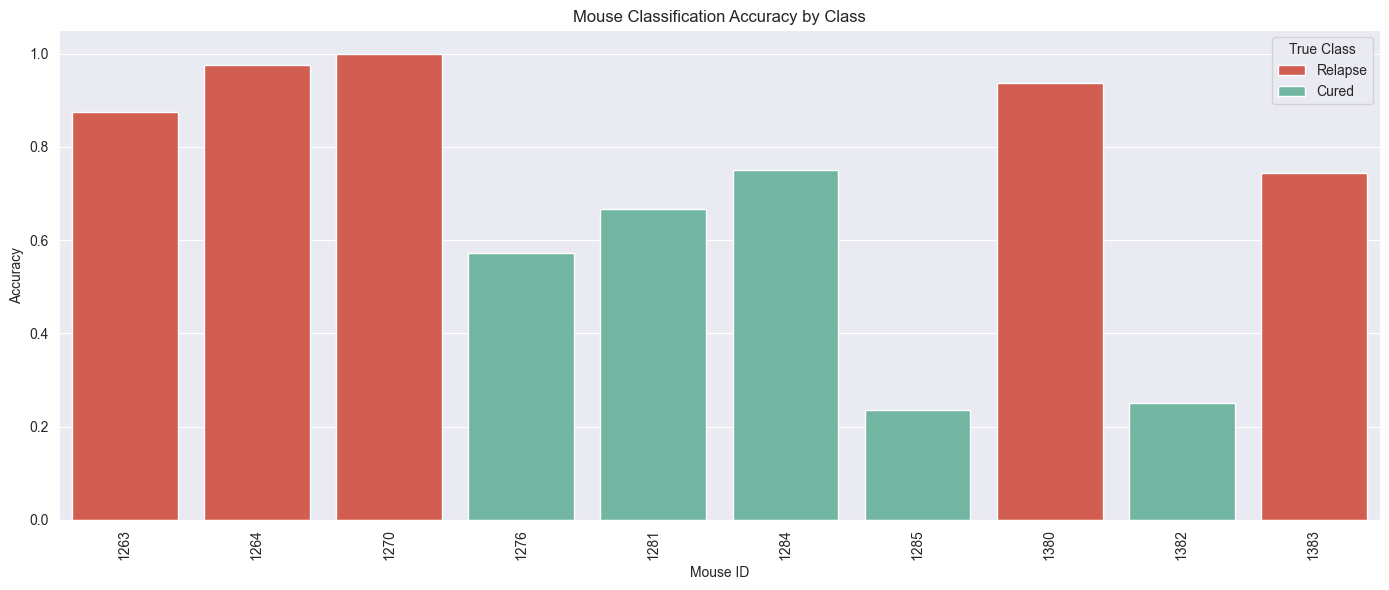

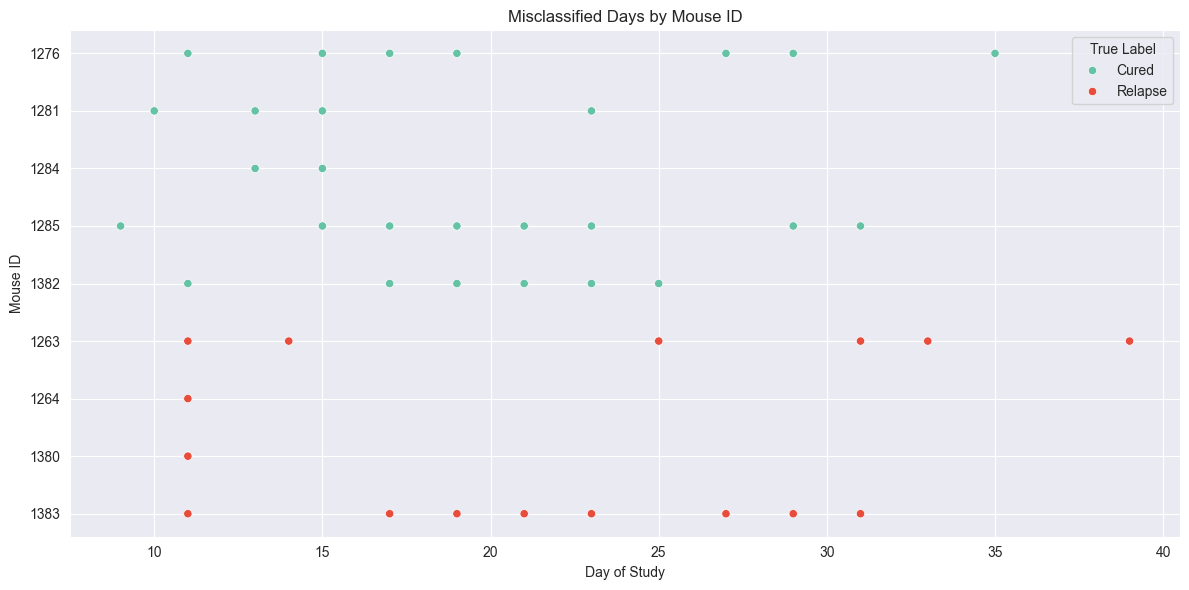

In [505]:
import seaborn as sns
import matplotlib.pyplot as plt

# Concatenar resultados de todos los folds
all_mice = pd.concat(fold_results.values(), ignore_index=True)

# Encuentra todas las columnas que comienzan con "m_id_"
id_cols = [col for col in all_mice.columns if col.startswith("m_id_")]

# Crea una nueva columna "mouse_id" tomando el primer valor no nulo en las columnas de ID
all_mice["mouse_id"] = all_mice[id_cols].bfill(axis=1).iloc[:, 0]

# Luego eliminamos las columnas viejas
all_mice.drop(columns=id_cols, inplace=True)

# Calcular total de predicciones y accuracy
all_mice["total_preds"] = all_mice["well_predicted_count"] + all_mice["bad_predicted_count"]
all_mice["accuracy"] = all_mice["well_predicted_count"] / all_mice["total_preds"]

# Mapear clase 0,1 a texto
label_map = {0: "Relapse", 1: "Cured"}
all_mice["class_label"] = all_mice["true_label"].map(label_map)

sns.set_style("darkgrid")

# Convertir "mouse_id" a int
all_mice["mouse_id"] = all_mice["mouse_id"].astype(int)

# Definir nueva paleta personalizada
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

plt.figure(figsize=(14, 6))
sns.barplot(
    data=all_mice,
    x="mouse_id",
    y="accuracy",
    hue="class_label",
    palette=palette  # 👈 colores nuevos
)
plt.xticks(rotation=90)
plt.title("Mouse Classification Accuracy by Class")
plt.ylabel("Accuracy")
plt.xlabel("Mouse ID")
plt.legend(title="True Class")
plt.tight_layout()
plt.show()


# print(all_mice)
# Expandir para hacer un punto por cada día fallado
error_days = []
for idx, row in all_mice.iterrows():
    for day in row["bad_predicted_days"]:
        error_days.append({
            "Mouse ID": int(row["mouse_id"]),
            "Day of Study": day,
            "True Label": row["class_label"]
        })

error_days_df = pd.DataFrame(error_days)
sns.set_style("darkgrid")
palette = {"Relapse": "#e74c3c", "Cured": "#66c2a5"}

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=error_days_df,
    x="Day of Study",
    y=error_days_df["Mouse ID"].astype(str),  # 👈 pasamos a texto para que los trate como categorías
    hue="True Label",
    palette=palette
)
# English
plt.title("Misclassified Days by Mouse ID")
plt.xlabel("Day of Study")
plt.ylabel("Mouse ID")
plt.tight_layout()
plt.show()


===== Global Metrics =====
Accuracy: 0.8121
ROC AUC: 0.6950
Sensitivity (Recall/TPR): 0.4848
Specificity (TNR): 0.9052
PPV (Precision): 0.5926
NPV: 0.8607
F1 Score (Weighted): 0.8051
F1 Score: 0.7078

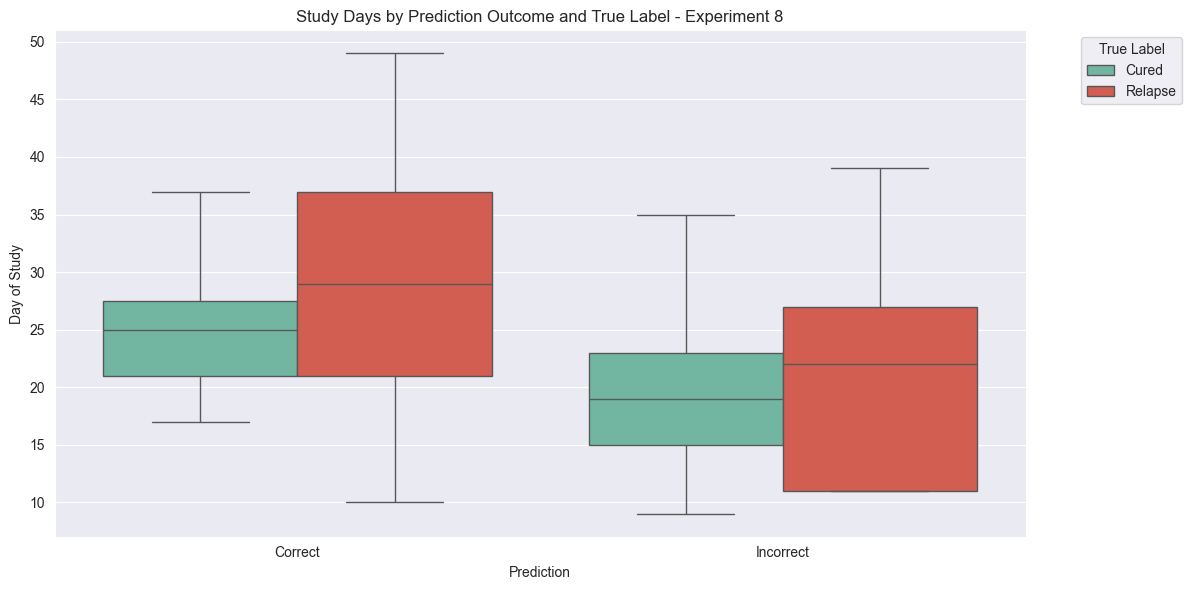

In [506]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    # Mapeo de etiquetas numéricas a texto
    label_map = {0: "Relapse", 1: "Cured"}

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = label_map[row["true_label"]]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)
    
    sns.set_style("darkgrid")
    # Crear el gráfico
    plt.figure(figsize=(12, 6))

    ax = sns.boxplot(
        data=df_plot, 
        x="Prediction", 
        y="Day", 
        hue="True Label", 
        palette=palette, 
        fliersize=0
    )

    # Ajustar leyenda
    handles, labels = ax.get_legend_handles_labels()
    n_labels = len(df_plot["True Label"].unique())
    plt.legend(handles[:n_labels], labels[:n_labels], title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Títulos y ejes
    plt.title("Study Days by Prediction Outcome and True Label - Experiment 8")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.tight_layout()

    # Guardar o mostrar
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

# Luego puedes llamar la función normalmente:
plot_prediction_days(fold_results)


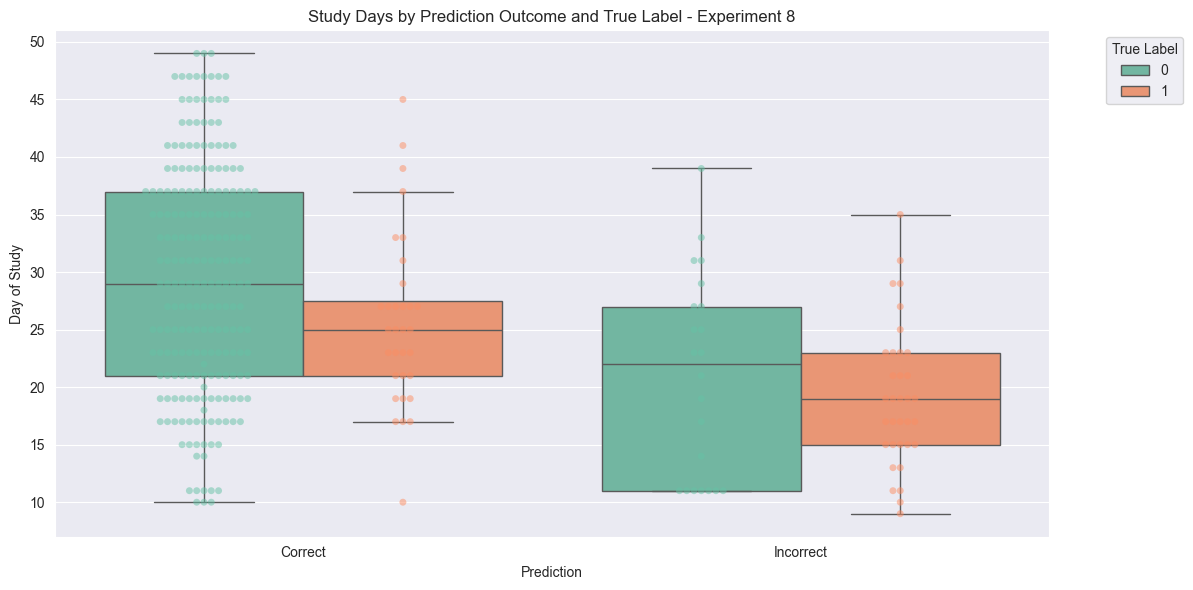

In [507]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(12, 6))

    ax = sns.boxplot(
        data=df_plot, 
        x="Prediction", 
        y="Day", 
        hue="True Label", 
        palette="Set2", 
        fliersize=0
    )

    sns.swarmplot(
        data=df_plot, 
        x="Prediction", 
        y="Day", 
        hue="True Label", 
        dodge=True, 
        palette="Set2", 
        alpha=0.5
    )

    # Eliminar la leyenda duplicada
    handles, labels = ax.get_legend_handles_labels()
    n_labels = len(df_plot["True Label"].unique())
    plt.legend(handles[:n_labels], labels[:n_labels], title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Títulos y ejes
    plt.title("Study Days by Prediction Outcome and True Label - Experiment 8")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.tight_layout()

    # Guardar o mostrar
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()


plot_prediction_days(fold_results)

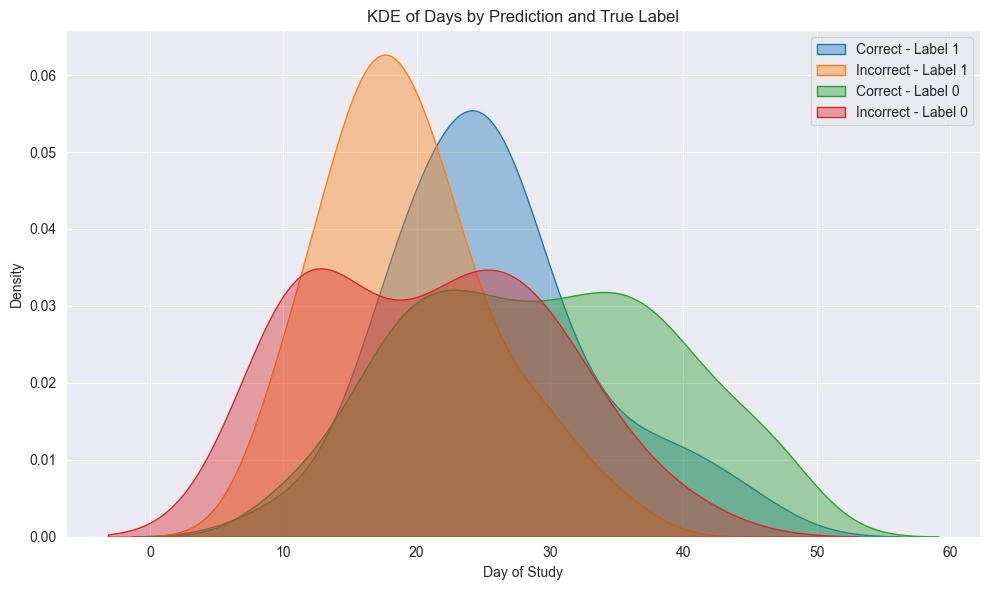

In [508]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    for label in df_plot["True Label"].unique():
        for pred_type in ["Correct", "Incorrect"]:
            subset = df_plot[(df_plot["True Label"] == label) & (df_plot["Prediction"] == pred_type)]
            sns.kdeplot(subset["Day"], label=f"{pred_type} - Label {label}", fill=True, alpha=0.4)

    plt.title("KDE of Days by Prediction and True Label")
    plt.xlabel("Day of Study")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

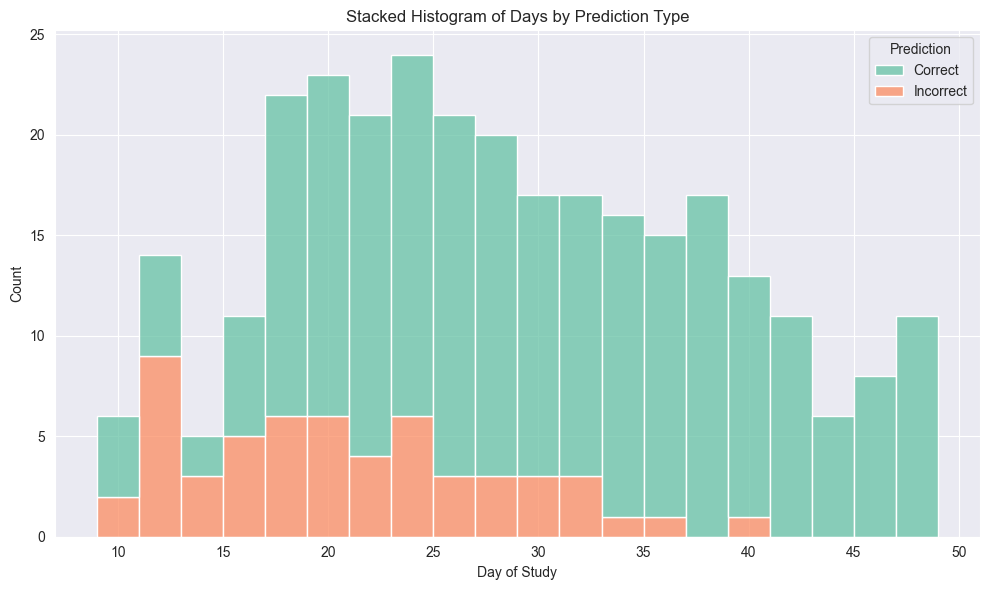

In [509]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_plot, x="Day", hue="Prediction", multiple="stack", bins=20, palette="Set2")
    plt.title("Stacked Histogram of Days by Prediction Type")
    plt.xlabel("Day of Study")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

### 9-Heuristic LF Var HC NOSF Features UnderSampling No Control Cases again HEURISTIC

In [510]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/baseline_no_control_heuristic_lf_NOsf_var_hc_undersample_reduce_again_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count              well_predicted_days  bad_predicted_count                                   bad_predicted_days
      1276           1                     8 [23, 25, 27, 35, 37, 39, 41, 45]                   13 [11, 15, 17, 17, 19, 19, 23, 25, 27, 29, 31, 33, 33]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     8 [17, 17, 19, 19, 21, 21, 23, 27]                    4   [10, 13, 15, 23]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count      well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     6 [10, 17, 19, 21, 23, 27]                    2           [13, 15]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                  bad_predicted_days
      1285           1

In [511]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/RF_baseline_no_control_heuristic_lf_NOsf_var_hc_oversample_reduce_again_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                                   bad_predicted_days
      1276           1                     4    [23, 25, 27, 31]                   17 [11, 15, 17, 17, 19, 19, 23, 25, 27, 29, 33, 33, 35, 37, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count              well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     8 [10, 17, 17, 19, 21, 21, 23, 27]                    4   [13, 15, 19, 23]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count      well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     6 [10, 17, 19, 21, 23, 27]                    2           [13, 15]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                  bad_predicted_days
      1285      

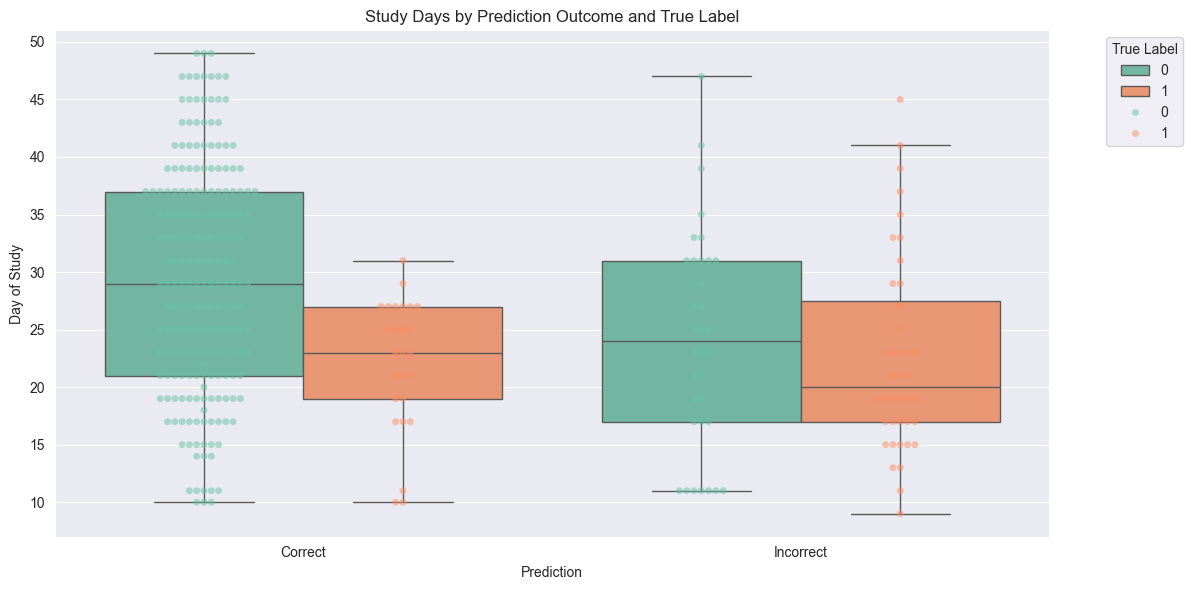

In [512]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prediction_days(fold_results, save_path=None):
    """
    Crea un gráfico tipo boxplot con los días bien y mal clasificados por fold y etiqueta real.
    
    Parameters:
    - fold_results: dict de resultados por fold (como se construye en tu código)
    - save_path: ruta para guardar la figura (opcional)
    """
    # Lista para acumular los datos
    plot_data = []

    for fold, df in fold_results.items():
        for _, row in df.iterrows():
            true_label = row["true_label"]
            m_id = row[df.columns[0]]  # columna del ID del ratón
            
            for day in row["well_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Correct",
                    "True Label": true_label,
                    "Fold": fold
                })
            for day in row["bad_predicted_days"]:
                plot_data.append({
                    "Mouse ID": m_id,
                    "Day": day,
                    "Prediction": "Incorrect",
                    "True Label": true_label,
                    "Fold": fold
                })

    # Convertir a DataFrame
    df_plot = pd.DataFrame(plot_data)

    # Crear el gráfico
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x="Prediction", y="Day", hue="True Label", palette="Set2", fliersize=0)
    sns.swarmplot(data=df_plot, x="Prediction", y="Day", hue="True Label", dodge=True, palette="Set2", alpha=0.5)
    plt.title("Study Days by Prediction Outcome and True Label")
    plt.xlabel("Prediction")
    plt.ylabel("Day of Study")
    plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

plot_prediction_days(fold_results)

In [513]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output_final1/hyp3/RF/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')



===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count                  well_predicted_days  bad_predicted_count                               bad_predicted_days
      1276           1                     9 [19, 23, 23, 25, 25, 27, 27, 37, 45]                   12 [11, 15, 17, 17, 19, 29, 31, 33, 33, 35, 39, 41]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count          well_predicted_days  bad_predicted_count   bad_predicted_days
      1281           1                     7 [17, 19, 21, 21, 23, 23, 27]                    5 [10, 13, 15, 17, 19]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     4    [19, 21, 23, 27]                    4   [10, 13, 15, 17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                  bad_predicted_days
      1285           1              

In [514]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 16
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')



In [515]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output11111/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')

FileNotFoundError: [Errno 2] No such file or directory: 'output11111/grouped_combinations_split_with_sampling/fold_0/misclassified.csv'

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "outputbest/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 10
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_nocontrol_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 10
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_nocontrol_lagfeatures_heuristic_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 10
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

f1_score_ = f1_score(y_true_all, y_pred_all, average='macro')  # F1 Score para clasificación binaria
f1_weighted = f1_score(y_true_all, y_pred_all, average='weighted')

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
print(f'F1 Score (Weighted): {f1_weighted:.4f}')
print(f'F1 Score: {f1_score_:.4f}')


===== Fold 0 =====
 m_id_1276  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                                   bad_predicted_days
      1276           1                     4    [25, 25, 27, 35]                   17 [11, 15, 17, 17, 19, 19, 23, 23, 27, 29, 31, 33, 33, 37, 39, 41, 45]

===== Fold 1 =====
 m_id_1281  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    11 [10, 13, 15, 17, 19, 19, 21, 21, 23, 23, 27]                    1               [17]

===== Fold 2 =====
 m_id_1284  true_label  well_predicted_count      well_predicted_days  bad_predicted_count bad_predicted_days
      1284           1                     6 [13, 15, 19, 21, 23, 27]                    2           [10, 17]

===== Fold 3 =====
 m_id_1285  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                          bad

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr_new/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')
# from sklearn.metrics import average_precision_score

# pr_auc = average_precision_score(y_true_all, y_pred_all)

# # Mostrar PR AUC
# print(f'PR AUC: {pr_auc:.4f}')

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 10
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/new/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_classweights_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allfeatures/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')


In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
# data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
# NUM_FOLDS = 18
# # Listas para acumular todas las etiquetas y predicciones
# y_true_all = []
# y_pred_all = []

# # Diccionario para almacenar resultados por fold
# fold_results = {}

# # Para cada fold, cargamos los datos guardados
# for fold in range(NUM_FOLDS):  
#     misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
#     well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

#     # Unimos todos los valores verdaderos y predicciones
#     y_true_all.extend(misclassified["true_label"].tolist())
#     y_pred_all.extend(misclassified["predicted_label"].tolist())

#     y_true_all.extend(well_classified["true_label"].tolist())
#     y_pred_all.extend(well_classified["predicted_label"].tolist())

#     # Obtener la columna de ID de ratón
#     id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
#     # Contar bien y mal predichos por ratón
#     misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
#     ).reset_index()

#     well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
#         well_predicted_count="count", well_predicted_days=lambda x: list(x)
#     ).reset_index()

#     # Unir ambas tablas
#     results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

#     # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
#     results["bad_predicted_count"].fillna(0, inplace=True)
#     results["well_predicted_count"].fillna(0, inplace=True)
#     results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

#     # Guardar resultados en un diccionario
#     fold_results[fold] = results

#     # Imprimir resultados para este fold
#     print(f"\n===== Fold {fold} =====")
#     print(results.to_string(index=False))

# # Convertimos a arrays NumPy
# y_true_all = np.array(y_true_all)
# y_pred_all = np.array(y_pred_all)

# # Calcular métricas globales
# accuracy = accuracy_score(y_true_all, y_pred_all)
# roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
# tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

# sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
# ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
# npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# # Mostrar métricas globales
# print("\n===== Global Metrics =====")
# print(f'Accuracy: {accuracy:.4f}')
# print(f'ROC AUC: {roc_auc:.4f}')
# print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
# print(f'Specificity (TNR): {specificity:.4f}')
# print(f'PPV (Precision): {ppv:.4f}')
# print(f'NPV: {npv:.4f}')
